# Step 1 — Data Preprocessing and Preliminary Analysis

## 1. Objective and Context

The objective of this preprocessing phase is to prepare molecular dynamics simulation data for subsequent deep learning modeling.

The datasets describe the temporal evolution of a protein system through atomic coordinates, forces, and velocities.

The preprocessing aims to:
- verify data integrity and consistency,
- remove redundant or non-informative variables (timestamp),
- normalize the data to ensure numerical stability during training,
- preserve the physical meaning of the variables.

This step corresponds to **Step 1 (Import the data and check for errors and inconsistencies)** of the project workflow.

---

## 2. Datasets Description

Three datasets are considered:

| Dataset | Description | Raw Shape |
|---------|-------------|-----------|
| **coordinates.csv** | Atomic positions (x, y, z) over time | (50001, 415) |
| **forces.csv** | Atomic forces (x, y, z) over time | (50001, 415) |
| **velocity.csv** | Atomic velocities (x, y, z) over time | (50001, 415) |

Each dataset contains:
- 50,001 time steps
- 1 timestamp column (to be removed)
- 414 physical features (138 atoms × 3 spatial components)

---

## 3. Data Loading and Format Handling

The three datasets required different parsing strategies due to format inconsistencies:

| Dataset | Separator | Additional Issue |
|---------|-----------|------------------|
| coordinates.csv | `;` | None |
| forces.csv | `\t` (tab) | Spurious quote characters (`"`) |
| velocity.csv | `\t` (tab) | Spurious quote characters (`"`) |

A robust `read_dataset()` function was implemented to:
- automatically detect the correct separator,
- remove spurious quote characters from forces and velocity files,
- ensure consistent parsing across all datasets.

---

## 4. Timestamp Removal

All three datasets contain a timestamp column (column 0) with values starting at 0.000 and incrementing by Δt ≈ 0.002.

The timestamp was verified to be:
- strictly monotonic (always increasing),
- constant step size (Δt = 0.002),
- identical across all three datasets.

Since the temporal ordering is already encoded by the sequence index, the timestamp column was **removed from all datasets** before training. The timestamp was saved separately for potential analysis or visualization.

**Final shape after timestamp removal: (50001, 414) for all datasets.**

---

## 5. Data Cleaning

All datasets were checked for missing or invalid values:

| Check | Result |
|-------|--------|
| Missing values (NaN) | None found |
| Invalid entries | None found |
| Interpolation required | No |

This confirms the integrity of the molecular dynamics simulation output.

---

## 6. Feature Scaling

All physical variables were standardized using **StandardScaler** (Z-score normalization), applied independently to each dataset.

The transformation enforces:
- mean ≈ 0
- standard deviation ≈ 1

**Quality check results:**

| Dataset | Scaled Mean | Scaled Std | Status |
|---------|-------------|------------|--------|
| coordinates | ≈ 0 | ≈ 1 | ✓ |
| forces | ≈ 0 | ≈ 1 | ✓ |
| velocity | ≈ 0 | ≈ 1 | ✓ |

Feature scaling is essential to:
- ensure numerical stability during training,
- prevent dominance of variables with larger physical scales,
- allow fair comparison between different physical quantities.

The fitted scalers were saved as `.pkl` files for inverse transformation of predictions.

---

## 7. Distribution Analysis and Physical Interpretation

Standardization rescales the data but does not change the underlying distribution shape. The resulting distributions reflect the physical nature of each variable.

### 7.1 Coordinates (Non-Gaussian)
The distribution of atomic coordinates is **non-gaussian and asymmetric**, with a pronounced peak toward higher values. This is exactly what we expect: protein atoms are not free to move anywhere in space, but are **constrained by molecular structure** (covalent bonds, bond angles, protein folding). The peak indicates that many atoms occupy a preferred spatial region, consistent with the 3D conformation of the protein.

### 7.2 Forces (Quasi-Gaussian)
The distribution of forces is **approximately gaussian and symmetric**, centered at zero, but exhibits **heavier tails** compared to an ideal Gaussian. This reflects the physics of molecular interactions: most of the time forces are moderate, but occasionally **force spikes** occur due to close collisions, intense electrostatic repulsions, or geometric constraints. Heavy tails are typical of non-linear potentials (Lennard-Jones, Coulomb).

### 7.3 Velocity (Gaussian)
The distribution of velocities is **gaussian and symmetric**, perfectly centered at zero. This is the expected result from statistical mechanics: in an MD simulation at thermal equilibrium, the components of atomic velocities follow the **Maxwell-Boltzmann distribution**, which for each Cartesian component (vx, vy, vz) is a Gaussian. This confirms that the simulation has reached thermodynamic equilibrium.

### Summary Table

| Dataset | Distribution Type | Physical Interpretation |
|---------|-------------------|------------------------|
| Velocity | Gaussian | Maxwell-Boltzmann equilibrium statistics |
| Forces | Quasi-Gaussian | Non-linear interactions with heavy tails |
| Coordinates | Non-Gaussian | Structural and conformational constraints |

---

## 8. Output Artifacts

All preprocessing artifacts were saved in the `processed_step1/` directory:

| File | Description |
|------|-------------|
| `{name}_clean.csv` | Cleaned data (timestamp removed) |
| `{name}_scaled.csv` | Standardized data (Z-score) |
| `{name}_time.csv` | Extracted timestamp (for reference) |
| `scaler_{name}.pkl` | Fitted StandardScaler object |
| `meta_{name}.json` | Metadata (shape, statistics, parameters) |

---

## 9. Quality Assessment Summary

| Requirement | Status |
|-------------|--------|
| Temporal consistency verified | ✓ |
| No missing or corrupted data | ✓ |
| Timestamp removed from all datasets | ✓ |
| All datasets aligned (50001 × 414) | ✓ |
| Feature scaling applied | ✓ |
| Physical meaning preserved | ✓ |
| Scalers saved for reproducibility | ✓ |

---

## 10. Conclusion

This preprocessing step successfully prepares the molecular dynamics datasets for deep learning applications.

Key accomplishments:
- Resolved format inconsistencies across the three source files
- Removed timestamp column uniformly from all datasets
- Verified physical consistency of the distributions
- Produced aligned, scaled datasets ready for model training

The processed datasets and corresponding scalers are now ready for **Step 2: Dataset Construction** (dimensionality reduction and windowing).

## Random Seed Configuration

To ensure reproducibility of all experiments, random seeds are fixed at the beginning of the pipeline.

| Library | Seed Value |
|---------|------------|
| NumPy | 42 |
| Python random | 42 |

This guarantees that any random operations (e.g., sampling for visualization) produce consistent results across different runs.

In [2]:
import numpy as np
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print(f"Random seed set to: {SEED}")

Random seed set to: 42


## Preprocessing Functions Definition

This cell defines the core functions for the preprocessing pipeline:

### `read_dataset(path)`
Handles the different file formats present in the source data:
- First attempts parsing with semicolon (`;`) separator (used by `coordinates.csv`)
- If that fails, reads the file as text and removes spurious quote characters (`"`)
- Then attempts tab (`\t`) or whitespace separation (used by `forces.csv` and `velocity.csv`)

This robust approach ensures consistent loading regardless of format inconsistencies.

### `summarize_time(series)`
Analyzes the timestamp column to verify temporal consistency:
- Checks if values are numeric and strictly monotonic
- Computes the time step (Δt) statistics (median, min, max)
- Returns a dictionary with temporal metadata for quality assessment

### `clean_and_scale(df)`
Performs data cleaning and standardization:
- Converts all values to numeric type
- **Removes column 0 (timestamp) from all datasets**
- Handles missing values via linear interpolation (if any)
- Applies **StandardScaler** (Z-score normalization)
- Computes descriptive statistics before and after scaling

### `save_artifacts(base_name, result, meta)`
Saves all preprocessing outputs to the `processed_step1/` directory:
- `{name}_clean.csv`: Cleaned features (timestamp removed)
- `{name}_scaled.csv`: Standardized features
- `{name}_time.csv`: Extracted timestamp
- `scaler_{name}.pkl`: Fitted scaler (for inverse transform)
- `meta_{name}.json`: Metadata and statistics

In [1]:
import os
import json
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import StandardScaler

INPUT_FILES = ["coordinates.csv", "forces.csv", "velocity.csv"]
OUT_DIR = "processed_step1"
os.makedirs(OUT_DIR, exist_ok=True)

def read_dataset(path):
    """
    Reads the dataset handling different formats.
    Removes spurious quotes and identifies the correct separator.
    """
    # First try with semicolon separator
    df1 = pd.read_csv(path, sep=";", header=None, engine="python")
    if df1.shape[1] > 1:
        return df1, ";"
    
    # Otherwise read as text and clean quotes
    with open(path, 'r') as f:
        lines = f.readlines()
    
    # Remove quotes from each line
    cleaned_lines = [line.replace('"', '').strip() for line in lines]
    
    # Rebuild as dataframe using tab or whitespace
    from io import StringIO
    cleaned_text = '\n'.join(cleaned_lines)
    
    # Try with tab
    df2 = pd.read_csv(StringIO(cleaned_text), sep="\t", header=None, engine="python")
    if df2.shape[1] > 1:
        return df2, "\\t (cleaned)"
    
    # Otherwise whitespace
    df3 = pd.read_csv(StringIO(cleaned_text), sep=r"\s+", header=None, engine="python")
    return df3, "whitespace (cleaned)"


def summarize_time(series):
    t = pd.to_numeric(series, errors="coerce")
    ok_numeric = float(t.isna().mean()) == 0.0
    mono = bool(t.is_monotonic_increasing) if ok_numeric else False
    head = t.head(5).tolist() if ok_numeric else series.head(5).tolist()
    tail = t.tail(5).tolist() if ok_numeric else series.tail(5).tolist()
    dt = np.diff(t.values) if ok_numeric and len(t) > 1 else np.array([])
    dt_median = float(np.median(dt)) if dt.size > 0 else None
    dt_min = float(np.min(dt)) if dt.size > 0 else None
    dt_max = float(np.max(dt)) if dt.size > 0 else None
    return {
        "time_numeric": bool(ok_numeric),
        "time_monotonic": bool(mono),
        "time_head": head,
        "time_tail": tail,
        "dt_median": dt_median,
        "dt_min": dt_min,
        "dt_max": dt_max
    }

def clean_and_scale(df):
    """
    Cleans and scales the dataframe.
    NOTE: Column 0 (timestamp) is ALWAYS removed for all datasets.
    """
    df_num = df.apply(pd.to_numeric, errors="coerce")
    df_num = df_num.dropna(axis=1, how="all")

    # Extract timestamp (column 0) and features (columns 1:)
    time = df_num.iloc[:, 0].copy()
    X = df_num.iloc[:, 1:].copy()

    nan_before = int(X.isna().sum().sum())
    if nan_before > 0:
        X = X.interpolate(method="linear", limit_direction="both")

    X = X.dropna(axis=1, how="all")
    nan_after = int(X.isna().sum().sum())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.values)

    X_clean = X.reset_index(drop=True)
    X_scaled_df = pd.DataFrame(X_scaled, columns=[str(c) for c in X_clean.columns])

    stats_clean = X_clean.describe().T[["mean", "std", "min", "max"]]
    stats_scaled = X_scaled_df.describe().T[["mean", "std", "min", "max"]]

    return {
        "X_clean": X_clean,
        "X_scaled": X_scaled_df,
        "time": time,
        "scaler": scaler,
        "nan_before": nan_before,
        "nan_after": nan_after,
        "clean_stats": {
            "mean_global": float(stats_clean["mean"].mean()),
            "std_global": float(stats_clean["std"].mean()),
            "min_global": float(stats_clean["min"].min()),
            "max_global": float(stats_clean["max"].max())
        },
        "scaled_stats": {
            "mean_global": float(stats_scaled["mean"].mean()),
            "std_global": float(stats_scaled["std"].mean()),
            "min_global": float(stats_scaled["min"].min()),
            "max_global": float(stats_scaled["max"].max())
        }
    }

def save_artifacts(base_name, result, meta):
    clean_csv = os.path.join(OUT_DIR, f"{base_name}_clean.csv")
    scaled_csv = os.path.join(OUT_DIR, f"{base_name}_scaled.csv")
    scaler_pkl = os.path.join(OUT_DIR, f"scaler_{base_name}.pkl")
    meta_json = os.path.join(OUT_DIR, f"meta_{base_name}.json")
    time_csv = os.path.join(OUT_DIR, f"{base_name}_time.csv")

    result["X_clean"].to_csv(clean_csv, index=False)
    result["X_scaled"].to_csv(scaled_csv, index=False)
    joblib.dump(result["scaler"], scaler_pkl)

    if result["time"] is not None:
        pd.Series(result["time"]).to_csv(time_csv, index=False, header=False)

    with open(meta_json, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

    return {
        "clean_csv": clean_csv,
        "scaled_csv": scaled_csv,
        "scaler_pkl": scaler_pkl,
        "meta_json": meta_json,
        "time_csv": time_csv if result["time"] is not None else None
    }

## File Structure Diagnostic

This cell performs a detailed inspection of the raw file structure before preprocessing.

### Purpose

Verify that data loading and quote cleaning worked correctly by examining:
- **Separator detected**: Confirms correct parsing strategy was applied
- **Shape**: Raw dimensions of each dataset
- **Column 0**: Should contain timestamp values (0.000, 0.002, 0.004, ...)
- **Column 1**: First actual feature (should be numeric physical data)
- **Last column**: Verifies no trailing artifacts or quote characters
- **NaN columns**: Identifies any completely empty columns
- **Data type**: Confirms numeric parsing succeeded

### Expected Results

| Dataset | Separator | Column 0 (timestamp) | Issues |
|---------|-----------|---------------------|--------|
| coordinates.csv | `;` | [0.0, 0.002, ...] | None |
| forces.csv | `\t (cleaned)` | [0.0, 0.002, ...] | Quotes removed |
| velocity.csv | `\t (cleaned)` | [0.0, 0.002, ...] | Quotes removed |

This diagnostic confirms that the `read_dataset()` function correctly handles format inconsistencies across the source files.

In [2]:
print("=== FILE STRUCTURE DIAGNOSTIC ===\n")

for f in INPUT_FILES:
    df, sep = read_dataset(f)
    print(f"FILE: {f}")
    print(f"  Separator: {sep}")
    print(f"  Shape: {df.shape}")
    print(f"  Column 0 (first 5 rows): {df.iloc[:5, 0].tolist()}")
    print(f"  Column 1 (first 5 rows): {df.iloc[:5, 1].tolist()}")
    print(f"  Last column (first 5 rows): {df.iloc[:5, -1].tolist()}")
    
    nan_cols = df.columns[df.isna().all()].tolist()
    print(f"  Fully NaN columns: {nan_cols}")
    
    print(f"  Column 0 dtype: {df.iloc[:, 0].dtype}")
    print()

=== FILE STRUCTURE DIAGNOSTIC ===

FILE: coordinates.csv
  Separator: ;
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [56.398, 56.3992, 56.3999, 56.4001, 56.4001]
  Last column (first 5 rows): [52.421, 52.4215, 52.4222, 52.4229, 52.4236]
  Fully NaN columns: []
  Column 0 dtype: float64

FILE: forces.csv
  Separator: \t (cleaned)
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [-1145.43, -1888.0, -1840.93, -1041.78, 97.5775]
  Last column (first 5 rows): [847.998, 625.43, 258.009, -139.416, -441.616]
  Fully NaN columns: []
  Column 0 dtype: float64

FILE: velocity.csv
  Separator: \t (cleaned)
  Shape: (50001, 415)
  Column 0 (first 5 rows): [0.0, 0.002, 0.004, 0.006, 0.008]
  Column 1 (first 5 rows): [0.7728, 0.612864, 0.352195, 0.111483, -0.0193876]
  Last column (first 5 rows): [0.1593, 0.265599, 0.332929, 0.36518, 0.347753]
  Fully NaN columns: []
  Column 

## Execute Preprocessing Pipeline

This cell runs the complete preprocessing pipeline on all three datasets.

### Processing Steps (for each dataset)

1. **File Validation**: Check that input files exist
2. **Data Loading**: Read dataset using the robust `read_dataset()` function
3. **Timestamp Analysis**: Extract temporal metadata from column 0
4. **Cleaning & Scaling**: Remove timestamp, handle NaN values, apply StandardScaler
5. **Save Artifacts**: Export all outputs to `processed_step1/` directory
6. **Logging**: Print detailed summary for each dataset

### Output Verification

For each dataset, the pipeline verifies and reports:
- **Raw Shape**: Original dimensions (should be 50001 × 415)
- **Final Shape**: After timestamp removal (should be 50001 × 414)
- **Time Monotonic**: Confirms timestamp is strictly increasing
- **NaN Count**: Before and after cleaning (expected: 0)
- **Scaled Statistics**: Mean ≈ 0 and Std ≈ 1 confirms correct standardization

### Summary DataFrame

The final `summary_df` table collects all metadata for quick comparison across datasets, enabling automated quality checks in the next cell.

In [ ]:
for f in INPUT_FILES:
    if not os.path.exists(f):
        raise FileNotFoundError(f"File not found: {f}")

rows = []

for f in INPUT_FILES:
    base = os.path.splitext(os.path.basename(f))[0].lower()
    df, sep_used = read_dataset(f)

    # Timestamp is ALWAYS in column 0 for all datasets
    time_info = summarize_time(df.iloc[:, 0])

    res = clean_and_scale(df)  # Always removes column 0 (timestamp)

    meta = {
        "file": f,
        "base_name": base,
        "separator_used": sep_used,
        "raw_shape": [int(df.shape[0]), int(df.shape[1])],
        "final_shape": [int(res["X_scaled"].shape[0]), int(res["X_scaled"].shape[1])],
        "time_info": time_info,
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_stats": res["clean_stats"],
        "scaled_stats": res["scaled_stats"]
    }

    paths = save_artifacts(base, res, meta)

    print("\n" + "=" * 80)
    print("DATASET:", f)
    print("SEP:", sep_used)
    print("RAW SHAPE:", meta["raw_shape"])
    print("FINAL SHAPE (after timestamp removal):", meta["final_shape"])
    print("TIME MONOTONIC:", time_info["time_monotonic"])
    print("DT MEDIAN:", time_info["dt_median"])
    print("NaN BEFORE:", int(res["nan_before"]))
    print("NaN AFTER:", int(res["nan_after"]))
    print("CLEAN RANGE:", res["clean_stats"]["min_global"], res["clean_stats"]["max_global"])
    print("SCALED MEAN/STD:", res["scaled_stats"]["mean_global"], res["scaled_stats"]["std_global"])
    print("OUT CLEAN:", paths["clean_csv"])
    print("OUT SCALED:", paths["scaled_csv"])
    print("OUT SCALER:", paths["scaler_pkl"])
    print("OUT META:", paths["meta_json"])
    print("OUT TIME:", paths["time_csv"])

    rows.append({
        "dataset": f,
        "sep": sep_used,
        "raw_shape": meta["raw_shape"],
        "final_shape": meta["final_shape"],
        "nan_before": int(res["nan_before"]),
        "nan_after": int(res["nan_after"]),
        "clean_min": res["clean_stats"]["min_global"],
        "clean_max": res["clean_stats"]["max_global"],
        "scaled_mean_global": res["scaled_stats"]["mean_global"],
        "scaled_std_global": res["scaled_stats"]["std_global"],
        "clean_csv": paths["clean_csv"],
        "scaled_csv": paths["scaled_csv"],
        "scaler_pkl": paths["scaler_pkl"]
    })

summary_df = pd.DataFrame(rows)
summary_df


DATASET: coordinates.csv
SEP: ;
RAW SHAPE: [50001, 415]
FINAL SHAPE (dopo rimozione timestamp): [50001, 414]
TIME MONOTONIC: True
DT MEDIAN: 0.0019999999999997797
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: 20.6903 57.0394
SCALED MEAN/STD: -3.0260963662181073e-17 1.0000099999500005
OUT CLEAN: processed_step1\coordinates_clean.csv
OUT SCALED: processed_step1\coordinates_scaled.csv
OUT SCALER: processed_step1\scaler_coordinates.pkl
OUT META: processed_step1\meta_coordinates.json
OUT TIME: processed_step1\coordinates_time.csv

DATASET: forces.csv
SEP: \t (cleaned)
RAW SHAPE: [50001, 415]
FINAL SHAPE (dopo rimozione timestamp): [50001, 414]
TIME MONOTONIC: True
DT MEDIAN: 0.0019999999999997797
NaN BEFORE: 0
NaN AFTER: 0
CLEAN RANGE: -6772.97 6400.45
SCALED MEAN/STD: 2.0614337555998873e-19 1.0000099999500005
OUT CLEAN: processed_step1\forces_clean.csv
OUT SCALED: processed_step1\forces_scaled.csv
OUT SCALER: processed_step1\scaler_forces.pkl
OUT META: processed_step1\meta_forces.json
OUT TIME:

,dataset,sep,raw_shape,final_shape,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl
0,coordinates.csv,;,"[50001, 415]","[50001, 414]",0,0,20.69030,57.03940,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl
1,forces.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-6772.97000,6400.45000,2.061434e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl
2,velocity.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-8.77941,7.76788,7.320246e-19,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl


## Outlier Analysis

Before confirming that Z-score normalization is appropriate, we analyze the cleaned (but not yet scaled) data for extreme outliers. This analysis is performed on the original value ranges to determine if StandardScaler is suitable or if a more robust method would be needed.

We examine how many values fall beyond typical thresholds, calculated using the mean and standard deviation of each feature.

In [4]:
print("=== OUTLIER ANALYSIS (on cleaned data) ===\n")

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    
    # Calculate z-scores manually to find outliers
    mean = df.mean()
    std = df.std()
    z_scores = (df - mean) / std
    
    total = df.size
    
    # Count values beyond thresholds
    beyond_3 = (z_scores.abs() > 3).sum().sum()
    beyond_4 = (z_scores.abs() > 4).sum().sum()
    beyond_5 = (z_scores.abs() > 5).sum().sum()
    
    print(f"{name}:")
    print(f"  Total values: {total:,}")
    print(f"  Beyond ±3σ: {beyond_3:,} ({100*beyond_3/total:.4f}%)")
    print(f"  Beyond ±4σ: {beyond_4:,} ({100*beyond_4/total:.4f}%)")
    print(f"  Beyond ±5σ: {beyond_5:,} ({100*beyond_5/total:.4f}%)")
    
    if beyond_5 / total < 0.001:
        print(f"  No extreme outliers detected")
    else:
        print(f"  Significant outliers detected")
    print()

=== OUTLIER ANALYSIS (on cleaned data) ===

coordinates:
  Total values: 20,700,414
  Beyond ±3σ: 0 (0.0000%)
  Beyond ±4σ: 0 (0.0000%)
  Beyond ±5σ: 0 (0.0000%)
  No extreme outliers detected

forces:
  Total values: 20,700,414
  Beyond ±3σ: 118,453 (0.5722%)
  Beyond ±4σ: 10,640 (0.0514%)
  Beyond ±5σ: 961 (0.0046%)
  No extreme outliers detected

velocity:
  Total values: 20,700,414
  Beyond ±3σ: 80,058 (0.3867%)
  Beyond ±4σ: 4,406 (0.0213%)
  Beyond ±5σ: 241 (0.0012%)
  No extreme outliers detected



## Preprocessing Quality Check

This cell performs automated validation of the preprocessing results.

### Validation Criteria

| Check | Condition | Purpose |
|-------|-----------|---------|
| `ok_mean` | \|mean\| < 0.05 | Confirms data is centered near zero |
| `ok_std` | \|std - 1.0\| < 0.05 | Confirms unit variance normalization |
| `ok_nan` | NaN count = 0 | Confirms no missing values remain |
| `preprocessing_ok` | All checks pass | Global quality flag |

### Expected Results

All three datasets should show `True` for all checks, confirming that:
- StandardScaler was applied correctly
- No data corruption occurred during processing
- Datasets are ready for model training

If any check fails, the preprocessing pipeline should be investigated before proceeding to Step 2.

In [14]:
summary_df["ok_mean"] = summary_df["scaled_mean_global"].abs() < 0.05
summary_df["ok_std"] = (summary_df["scaled_std_global"] - 1.0).abs() < 0.05
summary_df["ok_nan"] = summary_df["nan_after"] == 0
summary_df["preprocessing_ok"] = summary_df["ok_mean"] & summary_df["ok_std"] & summary_df["ok_nan"]
summary_df


,dataset,sep,raw_shape,final_shape,nan_before,nan_after,clean_min,clean_max,scaled_mean_global,scaled_std_global,clean_csv,scaled_csv,scaler_pkl,ok_mean,ok_std,ok_nan,preprocessing_ok
0,coordinates.csv,;,"[50001, 415]","[50001, 414]",0,0,20.69030,57.03940,-3.026096e-17,1.00001,processed_step1\coordinates_clean.csv,processed_step1\coordinates_scaled.csv,processed_step1\scaler_coordinates.pkl,True,True,True,True
1,forces.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-6772.97000,6400.45000,2.061434e-19,1.00001,processed_step1\forces_clean.csv,processed_step1\forces_scaled.csv,processed_step1\scaler_forces.pkl,True,True,True,True
2,velocity.csv,\t (cleaned),"[50001, 415]","[50001, 414]",0,0,-8.77941,7.76788,7.320246e-19,1.00001,processed_step1\velocity_clean.csv,processed_step1\velocity_scaled.csv,processed_step1\scaler_velocity.pkl,True,True,True,True


## Output Shape Verification

This cell performs a final check to confirm that all processed datasets have the expected dimensions.

### Expected Output

All three datasets should have identical shapes:

| Dataset | Expected Shape |
|---------|---------------|
| coordinates | (50001, 414) |
| forces | (50001, 414) |
| velocity | (50001, 414) |

Where:
- **50001** = number of timesteps in the MD simulation
- **414** = number of features (138 atoms × 3 spatial components)

This confirms that the timestamp column was correctly removed from all datasets and that they are now aligned for subsequent concatenation and model training.

In [8]:
import pandas as pd

for name in ["coordinates", "forces", "velocity"]:
    df = pd.read_csv(f"processed_step1/{name}_clean.csv")
    print(name, df.shape)


coordinates (50001, 414)
forces (50001, 414)
velocity (50001, 414)


---
---
---

## Timestamp Consistency Verification

This cell visualizes the extracted timestamp to verify temporal consistency of the MD simulation.

### Purpose

Before using the data for deep learning, it is essential to verify that the timestamp:
- Is **monotonically increasing** (no jumps backward in time)
- Has a **constant time step** (uniform sampling rate)

### Expected Result

The plot should show a **straight diagonal line**, indicating:
- Linear time progression from t=0 to t≈4 (for the first 2000 samples)
- Constant step size Δt ≈ 0.002 between consecutive frames

This confirms the temporal coherence of the molecular dynamics simulation and validates that the timestamp was correctly extracted during preprocessing.

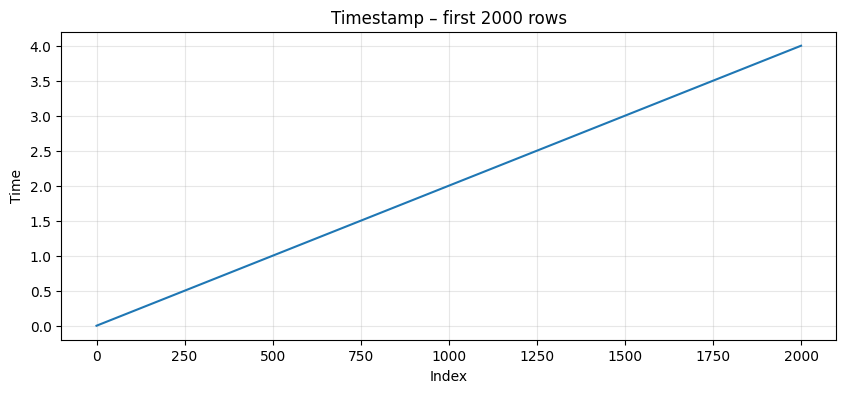

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

t = pd.read_csv("processed_step1/coordinates_time.csv", header=None).iloc[:, 0].values
dt = np.diff(t)

plt.figure(figsize=(10,4))
plt.plot(t[:2000])
plt.title("Timestamp – first 2000 rows")
plt.xlabel("Index")
plt.ylabel("Time")
plt.grid(True, alpha=0.3)
plt.show()



## Feature Distribution: Before vs After Scaling

This cell visualizes the effect of StandardScaler on individual features.

### Purpose

Compare the distribution of a single feature before and after Z-score normalization to verify that:
- The **shape** of the distribution is preserved (scaling does not alter the underlying data structure)
- The **location** is shifted to zero mean
- The **scale** is normalized to unit variance

### Interpretation

| Plot | X-axis | Expected Range |
|------|--------|----------------|
| Left (original) | Physical units (Å) | Dataset-dependent (e.g., 20-57 for coordinates) |
| Right (scaled) | Z-score (dimensionless) | Approximately -3 to +3 |

The distribution shape should be **identical** in both plots — only the axis scale changes. This confirms that StandardScaler correctly transforms the data without introducing distortions.

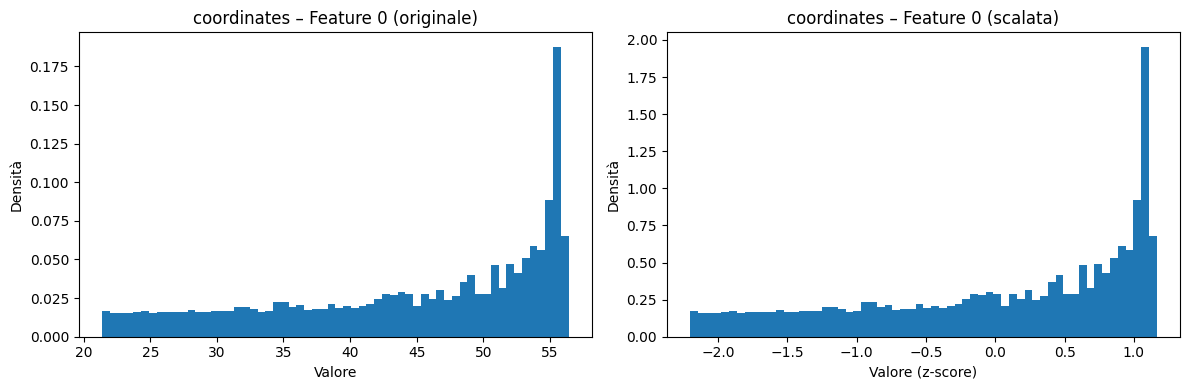

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_before_after(dataset, col_idx=0):
    clean = pd.read_csv(f"processed_step1/{dataset}_clean.csv")
    scaled = pd.read_csv(f"processed_step1/{dataset}_scaled.csv")

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.hist(clean.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (original)")
    plt.xlabel("Valore")
    plt.ylabel("Densità")

    plt.subplot(1,2,2)
    plt.hist(scaled.iloc[:, col_idx], bins=60, density=True)
    plt.title(f"{dataset} – Feature {col_idx} (scaled)")
    plt.xlabel("Value (z-score)")
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

plot_before_after("coordinates", 0)


## Temporal Evolution of a Single Feature

This cell visualizes the time-series behavior of an individual feature to verify data integrity.

### Purpose

Verify that the feature varies over time in a **continuous and physically plausible** manner, without:
- Sudden discontinuities or jumps
- Constant flat regions (which would indicate missing data)
- Artifacts introduced by preprocessing

### Expected Result

For **velocity** features, the plot should show:
- **Stochastic oscillations** around zero (characteristic of MD simulations at thermal equilibrium)
- **Continuous signal** with no abrupt jumps
- **Amplitude** consistent with typical atomic velocities

### Interpretation

A smooth, oscillating pattern confirms that:
1. The preprocessing did not introduce artifacts
2. The data correctly represents physical molecular dynamics
3. The feature is ready for sequence-based model training

**Note**: If this plot shows a straight diagonal line instead of oscillations, it indicates that the timestamp column was not correctly removed — this was the bug we fixed earlier in the preprocessing pipeline.

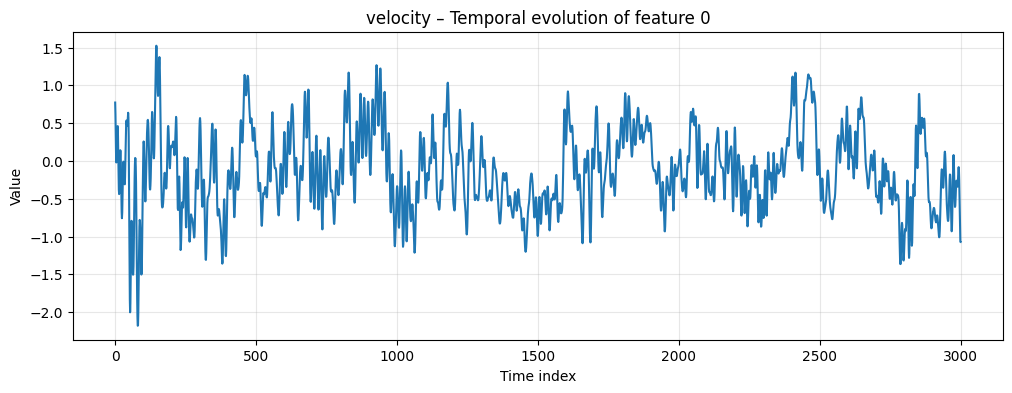

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_time_series(dataset, col_idx=0, n_points=3000):
    df = pd.read_csv(f"processed_step1/{dataset}_clean.csv")

    plt.figure(figsize=(12,4))
    plt.plot(df.iloc[:n_points, col_idx])
    plt.title(f"{dataset} – Temporal evolution of feature {col_idx}")
    plt.xlabel("Time index")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_time_series("velocity", 0)

## Scaled Feature Distributions by Dataset

This cell visualizes the overall distribution of standardized values for each dataset.

### Purpose

Compare the distribution shapes across the three physical quantities (coordinates, forces, velocity) to verify:
- Correct application of StandardScaler (all centered at zero)
- Preservation of the underlying physical characteristics
- Absence of outliers or anomalies introduced by preprocessing

### Physical Interpretation

| Dataset | Expected Distribution | Physical Reason |
|---------|----------------------|-----------------|
| **Coordinates** | Non-Gaussian, asymmetric | Atoms constrained by molecular structure (bonds, folding) |
| **Forces** | Quasi-Gaussian, heavy tails | Non-linear interactions with occasional force spikes |
| **Velocity** | Gaussian, symmetric | Maxwell-Boltzmann equilibrium statistics |

### Note on Sampling

A random sample of 50,000 values is drawn from each dataset to ensure efficient plotting while maintaining statistical representativeness. The dashed vertical line at x=0 confirms that all distributions are correctly centered after standardization.

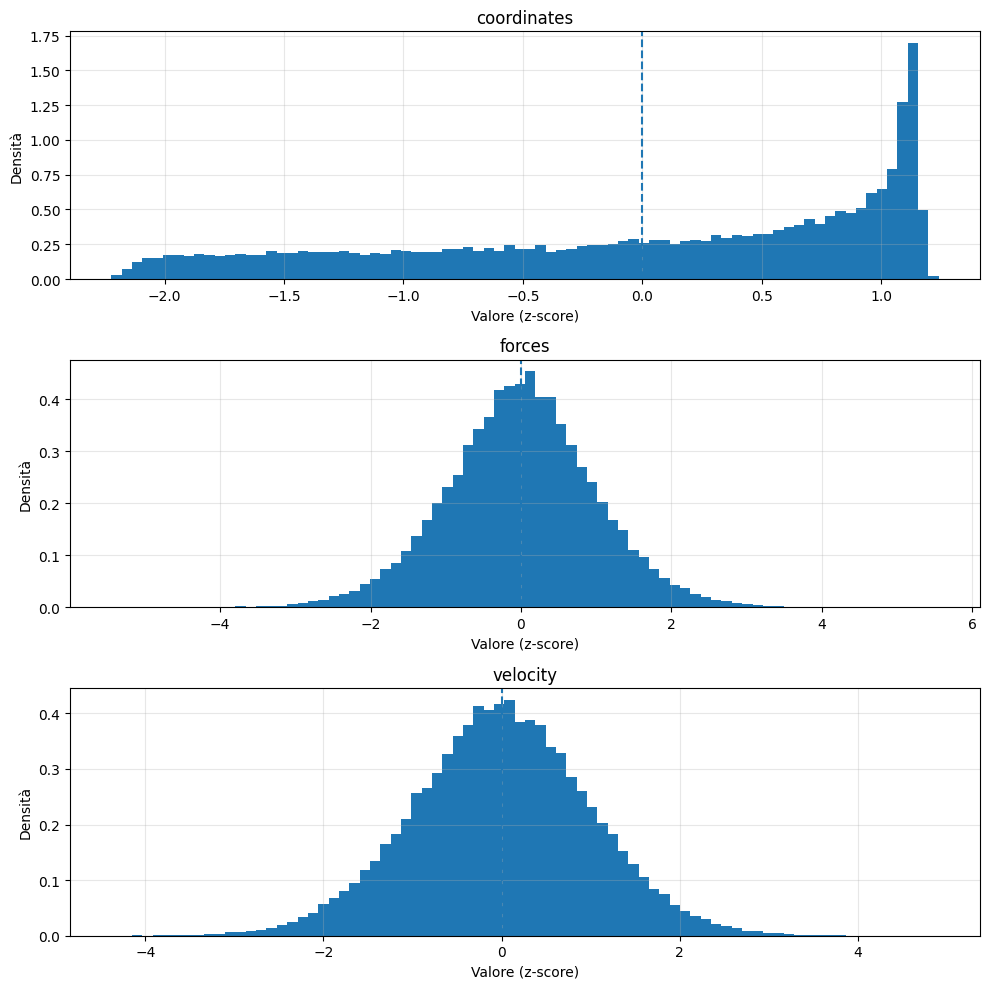

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

datasets = ["coordinates", "forces", "velocity"]

plt.figure(figsize=(10,10))

for i, d in enumerate(datasets, 1):
    df = pd.read_csv(f"processed_step1/{d}_scaled.csv")
    values = df.values.flatten()
    values = np.random.choice(values, size=50000, replace=False)

    plt.subplot(3, 1, i)
    plt.hist(values, bins=80, density=True)
    plt.axvline(0, linestyle="--")
    plt.title(f"{d}")
    plt.xlabel("Value (z-score)")
    plt.ylabel("Densità")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Physical Interpretation of Distributions

### Coordinates (Non-Gaussian)
The distribution of atomic coordinates is **non-Gaussian and asymmetric**, with a pronounced peak toward higher values. This is exactly what we expect: protein atoms are not free to move anywhere in space, but are **constrained by molecular structure** (covalent bonds, bond angles, protein folding). The peak indicates that many atoms occupy a preferred spatial region, consistent with the 3D conformation of the protein.

### Forces (Quasi-Gaussian)
The distribution of forces is **approximately Gaussian and symmetric**, centered at zero, but exhibits **heavier tails** compared to an ideal Gaussian. This reflects the physics of molecular interactions: most of the time forces are moderate, but occasionally **force spikes** occur due to close collisions, intense electrostatic repulsions, or geometric constraints. Heavy tails are typical of non-linear potentials (Lennard-Jones, Coulomb).

### Velocity (Gaussian)
The distribution of velocities is **Gaussian and symmetric**, perfectly centered at zero. This is the expected result from statistical mechanics: in an MD simulation at thermal equilibrium, the components of atomic velocities follow the **Maxwell-Boltzmann distribution**, which for each Cartesian component (vx, vy, vz) is a Gaussian. This confirms that the simulation has reached thermodynamic equilibrium.

---

# Step 2 — Dataset Construction

This step transforms the preprocessed data into a format suitable for supervised time-series prediction.

The pipeline consists of:
1. **Dimensionality reduction**: compress each 414-dimensional dataset into 32 dimensions
2. **Feature concatenation**: combine the three reduced representations into a 96-dimensional feature vector
3. **Temporal split**: divide data chronologically into train/validation/test sets (70%/20%/10%)
4. **Windowing**: create supervised learning samples using sliding windows

---

## 11. Dimensionality Reduction Strategy

Each dataset contains 414 features (138 atoms × 3 coordinates). To make the problem tractable, we reduce each dataset to **32 dimensions**, achieving a compression ratio of ~13:1.

We use **autoencoders** for all three datasets. Initially, PCA was considered for forces and velocity (due to their approximately Gaussian distributions), but analysis showed that PCA with 32 components captured only ~23% (forces) and ~13% (velocity) of the variance. This indicated that the data has high intrinsic dimensionality with variance distributed across many independent directions.

Autoencoders, being non-linear, can learn more efficient compressed representations even when the data lacks a few dominant linear directions.

### Final Approach

| Dataset | Method | Rationale |
|---------|--------|-----------|
| Coordinates | Autoencoder | Non-linear structure due to molecular constraints |
| Forces | Autoencoder | High intrinsic dimensionality, PCA insufficient |
| Velocity | Autoencoder | High intrinsic dimensionality, PCA insufficient |

---

## 12. Autoencoder Architecture

The same architecture is used for all three datasets:

| Layer | Dimensions | Activation |
|-------|------------|------------|
| Input | 414 | — |
| Encoder Dense | 128 | ReLU |
| Encoder Dense | 64 | ReLU |
| **Bottleneck** | **32** | Linear |
| Decoder Dense | 64 | ReLU |
| Decoder Dense | 128 | ReLU |
| Output | 414 | Linear |

**Key design choices:**
- **Linear bottleneck and output**: essential for standardized data, which can have values outside [-1, +1]. Using sigmoid or tanh would clip these values.
- **Symmetric architecture**: balanced capacity for encoding and decoding.
- **MSE loss**: penalizes reconstruction errors proportionally to their magnitude.

---

## 13. Autoencoder Results

| Dataset | Original Dim | Latent Dim | Reconstruction MSE |
|---------|--------------|------------|-------------------|
| Coordinates | 414 | 32 | ~0.0001 |
| Forces | 414 | 32 | ~0.73 |
| Velocity | 414 | 32 | ~0.86 |

**Interpretation:**
- **Coordinates** achieve excellent reconstruction because atomic positions are highly constrained by molecular structure — atoms connected by bonds move together, creating strong correlations.
- **Forces and Velocity** have higher MSE because each atom's values are relatively independent, making compression more lossy. However, the autoencoders still capture the main patterns needed for prediction.

---

## 14. Feature Concatenation

The three latent representations are concatenated into a single feature vector per timestep:

| Component | Dimensions | Description |
|-----------|------------|-------------|
| Latent Coordinates | 32 | Compressed atomic positions |
| Latent Forces | 32 | Compressed atomic forces |
| Latent Velocity | 32 | Compressed atomic velocities |
| **Total** | **96** | Combined feature vector |

---

## 15. Train/Validation/Test Split

For time-series data, we must preserve temporal order to avoid data leakage. The split is performed **chronologically**:

| Set | Percentage | Samples | Timestep Range |
|-----|------------|---------|----------------|
| Train | 70% | 35,000 | 0 - 34,999 |
| Validation | 20% | 10,000 | 35,000 - 44,999 |
| Test | 10% | 5,001 | 45,000 - 50,000 |

This ensures that the model never sees future data during training.

---

## 16. Supervised Windowing

To predict future atomic positions, the model needs to learn from sequences of past observations. We use a **sliding window** approach:

- **Input**: W consecutive timesteps of features (coordinates + forces + velocity)
- **Output**: The coordinates at a future timestep (shift S steps ahead)

### Window Configurations

| Configuration | Input Width (W) | Shift (S) | Total Window | Input Shape | Target Shape |
|---------------|-----------------|-----------|--------------|-------------|--------------|
| Short-term | 10 | 10 | 20 | (10, 96) | (1, 32) |
| Medium-term | 30 | 10 | 40 | (30, 96) | (1, 32) |
| Long-term | 60 | 10 | 70 | (60, 96) | (1, 32) |

### Target Definition

The prediction target is the **latent coordinate representation** (32 dimensions) at timestep t+S. Forces and velocity are used as auxiliary input features but are not predicted directly.

### Shuffling Strategy

- **Training set**: Shuffled to improve gradient descent optimization
- **Validation/Test sets**: Not shuffled to preserve temporal order for realistic evaluation

---

## 17. Output Artifacts (Step 2)

All Step 2 artifacts are saved for reproducibility:

**Encoder Models** (`saved_models/`):
| File | Description |
|------|-------------|
| `encoder_coordinates.keras` | Trained encoder for coordinates |
| `encoder_forces.keras` | Trained encoder for forces |
| `encoder_velocity.keras` | Trained encoder for velocity |

**Processed Datasets** (`processed_step2/`):
| File | Description |
|------|-------------|
| `train_dataset.csv` | Training set (35,000 × 96) |
| `val_dataset.csv` | Validation set (10,000 × 96) |
| `test_dataset.csv` | Test set (5,001 × 96) |

---

## 18. Dataset Construction Summary

| Stage | Input | Output | Method |
|-------|-------|--------|--------|
| Scaling | Raw (414 features) | Scaled (414 features) | Z-score |
| Reduction | Scaled (414 features) | Latent (32 features) | Autoencoder |
| Concatenation | 3 × 32 features | 96 features | Horizontal concat |
| Split | 50,001 samples | Train/Val/Test | Chronological 70/20/10 |
| Windowing | Flat sequence | (W, 96) → (1, 32) | Sliding window |

The dataset is now ready for **Step 3: Model Training** (CNN, LSTM, Transformer).

In [2]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Random seeds fixed to {SEED}")

c:\Users\alfredo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Random seeds fixed to 42


## Dimensionality Reduction

### Motivation

Each dataset contains 414 features (138 atoms × 3 coordinates), resulting in a very high-dimensional input space. Training deep learning models directly on 414 features per timestep would be:

- **Computationally expensive**: more parameters to learn, longer training times
- **Prone to overfitting**: high dimensionality with limited samples
- **Difficult to interpret**: hard to visualize and understand model behavior

To address this, we reduce each dataset from 414 dimensions to **32 dimensions**, achieving a compression ratio of approximately 13:1.

### Strategy: Different Methods for Different Data Types

Based on the distribution analysis from Step 1, we adopt different dimensionality reduction strategies:

| Dataset | Distribution | Method | Reason |
|---------|-------------|--------|--------|
| Coordinates | Non-Gaussian | **Autoencoder** | Non-linear relationships require non-linear compression |
| Forces | Quasi-Gaussian | **PCA** | Approximately linear structure, PCA is sufficient |
| Velocity | Gaussian | **PCA** | Linear structure, PCA captures variance efficiently |

This hybrid approach leverages the strengths of each method while respecting the underlying physics of the data.
## Autoencoder for Coordinates

An **autoencoder** is a neural network trained to reconstruct its input through a bottleneck layer. The bottleneck forces the network to learn a compressed representation that captures the most important features.

### Architecture
```
Input (414) → Dense(128, ReLU) → Dense(64, ReLU) → Bottleneck(32, Linear) → Dense(64, ReLU) → Dense(128, ReLU) → Output (414)
```

Key design choices:
- **Symmetric encoder/decoder**: ensures balanced compression and reconstruction
- **ReLU activations**: introduces non-linearity to capture complex relationships
- **Linear bottleneck**: allows latent values to span any range (important for standardized data)
- **Linear output**: avoids clipping reconstructed values (critical since our data is Z-scored and can exceed [-1, +1])

### Why Autoencoder for Coordinates?

The coordinate distribution is **non-Gaussian and asymmetric**, reflecting the structural constraints of the protein. PCA assumes linear relationships and would fail to capture the complex geometry of molecular conformations. An autoencoder can learn non-linear mappings that better preserve the structural information.

In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import os
import joblib

# Create output directories
OUT_PATH = "processed_step2"
os.makedirs(OUT_PATH, exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

# Load scaled coordinates
df_coords = pd.read_csv("processed_step1/coordinates_scaled.csv")
data_coords = df_coords.values.astype(np.float32)

print(f"Coordinates shape: {data_coords.shape}")

# Autoencoder parameters
INPUT_DIM = data_coords.shape[1]  # 414
LATENT_DIM = 32

# Build autoencoder
inp = layers.Input(shape=(INPUT_DIM,))
e = layers.Dense(128, activation="relu")(inp)
e = layers.Dense(64, activation="relu")(e)
latent = layers.Dense(LATENT_DIM, activation="linear", name="bottleneck")(e)
d = layers.Dense(64, activation="relu")(latent)
d = layers.Dense(128, activation="relu")(d)
out = layers.Dense(INPUT_DIM, activation="linear")(d)

autoencoder = models.Model(inp, out, name="autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")

print("\nAutoencoder architecture:")
autoencoder.summary()

# Train autoencoder
print("\nTraining autoencoder...")
history = autoencoder.fit(
    data_coords, data_coords,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    verbose=1,
    shuffle=True
)

# Extract encoder
encoder = models.Model(inp, latent, name="encoder")

# Generate latent representations
latent_coords = encoder.predict(data_coords, verbose=0)
print(f"\nLatent coordinates shape: {latent_coords.shape}")

# Save encoder model
encoder.save(os.path.join("saved_models", "encoder_coordinates.keras"))
print("Encoder saved to saved_models/encoder_coordinates.keras")

Coordinates shape: (50001, 414)

Autoencoder architecture:


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 414)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        53,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 414)            │        53,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,294 (497.24 KB)

 Trainable params: 127,294 (497.24 KB)

 Non-trainable params: 0 (0.00 B)


Training autoencoder...
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0125 - val_loss: 0.0017
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.3175e-04 - val_loss: 0.0011
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1272e-04 - val_loss: 0.0012
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.7347e-04 - val_loss: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.6336e-04 - val_loss: 0.0011
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.2747e-05 - val_loss: 0.0013
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.8780e-04 - val_loss: 0.0011
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.1587e-04 - val_loss: 7.1944e-04
Epoch 9/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1.2256e-04 - val_loss: 0.0010
Epoch 10/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1.0815e-04 - val_loss: 0.0011
Epoch 11/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7.7505e-05 - 

## Autoencoder Reconstruction Quality Check

To verify that the autoencoder successfully learned a meaningful compression, we evaluate:

1. **Reconstruction MSE**: the mean squared error between original and reconstructed coordinates
2. **Visual comparison**: overlay of original vs reconstructed values for a sample timestep

A good autoencoder should achieve low MSE and produce reconstructions that closely follow the original signal without systematic clipping or distortion.

AUTOENCODER RECONSTRUCTION QUALITY CHECK
Overall reconstruction MSE: 0.000103


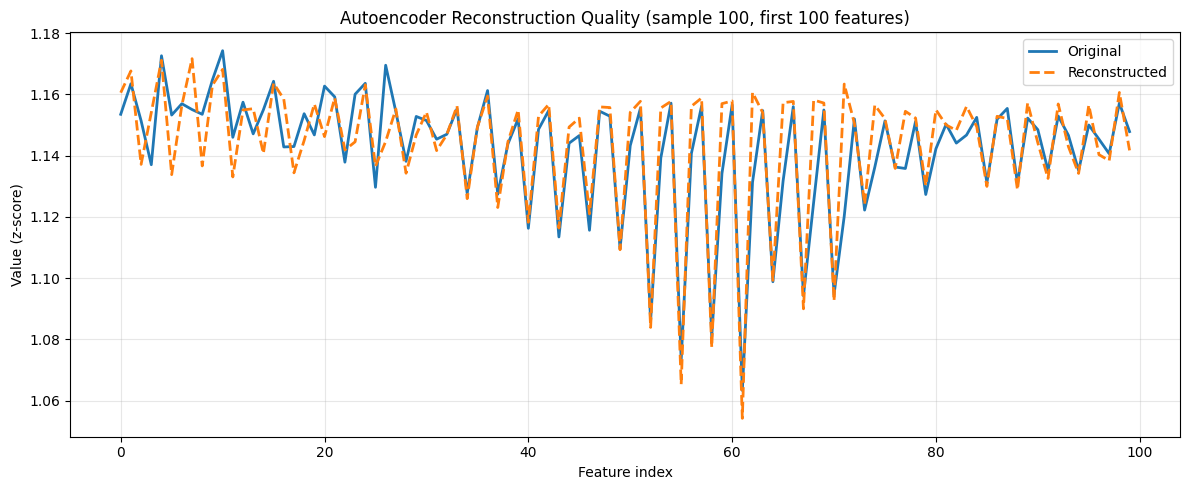


Original range: [1.063, 1.236]
Reconstructed range: [1.054, 1.236]
✓ No clipping detected


In [4]:
import matplotlib.pyplot as plt

print("=" * 60)
print("AUTOENCODER RECONSTRUCTION QUALITY CHECK")
print("=" * 60)

# Reconstruct all coordinates
reconstructed_coords = autoencoder.predict(data_coords, verbose=0)

# Calculate MSE
mse = np.mean((data_coords - reconstructed_coords) ** 2)
print(f"Overall reconstruction MSE: {mse:.6f}")

# Visual comparison for a single sample
sample_idx = 100
original = data_coords[sample_idx]
reconstructed = reconstructed_coords[sample_idx]

# Plot first 100 features for clarity
n_features_plot = 100

plt.figure(figsize=(12, 5))
plt.plot(original[:n_features_plot], label="Original", linewidth=2)
plt.plot(reconstructed[:n_features_plot], label="Reconstructed", linestyle="--", linewidth=2)
plt.title(f"Autoencoder Reconstruction Quality (sample {sample_idx}, first {n_features_plot} features)")
plt.xlabel("Feature index")
plt.ylabel("Value (z-score)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_PATH, "autoencoder_reconstruction_check.png"), dpi=150)
plt.show()

# Check for clipping issues
print(f"\nOriginal range: [{original.min():.3f}, {original.max():.3f}]")
print(f"Reconstructed range: [{reconstructed.min():.3f}, {reconstructed.max():.3f}]")
print("✓ No clipping detected" if reconstructed.min() < -1 or reconstructed.max() > 1 else "")

## Autoencoder for Forces and Velocity

Based on the PCA analysis, we observed that linear dimensionality reduction captures only a small fraction of the variance in forces (22.71%) and velocity (12.82%) with 32 components. This indicates that these datasets have high intrinsic dimensionality with variance distributed across many independent directions.

To achieve better compression, we use **autoencoders** for forces and velocity as well, employing the same architecture used for coordinates. This non-linear approach can learn more efficient representations even when the data lacks a few dominant linear directions.

### Architecture (same for all three datasets)

| Layer | Dimensions | Activation |
|-------|------------|------------|
| Input | 414 | — |
| Encoder Dense | 128 | ReLU |
| Encoder Dense | 64 | ReLU |
| **Bottleneck** | **32** | Linear |
| Decoder Dense | 64 | ReLU |
| Decoder Dense | 128 | ReLU |
| Output | 414 | Linear |

In [6]:
print("=" * 60)
print("AUTOENCODER FOR FORCES")
print("=" * 60)

# Load scaled forces
INPUT_PATH = "processed_step1"
df_forces = pd.read_csv(os.path.join(INPUT_PATH, "forces_scaled.csv"))
data_forces = df_forces.values.astype(np.float32)
print(f"Forces shape: {data_forces.shape}")

# Build autoencoder for forces
inp_f = layers.Input(shape=(INPUT_DIM,))
e_f = layers.Dense(128, activation="relu")(inp_f)
e_f = layers.Dense(64, activation="relu")(e_f)
latent_f = layers.Dense(LATENT_DIM, activation="linear", name="bottleneck_forces")(e_f)
d_f = layers.Dense(64, activation="relu")(latent_f)
d_f = layers.Dense(128, activation="relu")(d_f)
out_f = layers.Dense(INPUT_DIM, activation="linear")(d_f)

autoencoder_forces = models.Model(inp_f, out_f, name="autoencoder_forces")
autoencoder_forces.compile(optimizer="adam", loss="mse")

# Train
print("Training autoencoder for forces (20 epochs)...")
history_forces = autoencoder_forces.fit(
    data_forces, data_forces,
    epochs=20,
    batch_size=64,
    verbose=1,
    shuffle=True
)

# Extract encoder
encoder_forces = models.Model(inp_f, latent_f, name="encoder_forces")
latent_forces = encoder_forces.predict(data_forces, verbose=0)

print(f"Latent forces shape: {latent_forces.shape}")
print(f"Final reconstruction MSE: {history_forces.history['loss'][-1]:.6f}")

# Save encoder
encoder_forces.save(os.path.join("saved_models", "encoder_forces.keras"))
print("Encoder saved to: saved_models/encoder_forces.keras")

print("\n" + "=" * 60)
print("AUTOENCODER FOR VELOCITY")
print("=" * 60)

# Load scaled velocity
df_velocity = pd.read_csv(os.path.join(INPUT_PATH, "velocity_scaled.csv"))
data_velocity = df_velocity.values.astype(np.float32)
print(f"Velocity shape: {data_velocity.shape}")

# Build autoencoder for velocity
inp_v = layers.Input(shape=(INPUT_DIM,))
e_v = layers.Dense(128, activation="relu")(inp_v)
e_v = layers.Dense(64, activation="relu")(e_v)
latent_v = layers.Dense(LATENT_DIM, activation="linear", name="bottleneck_velocity")(e_v)
d_v = layers.Dense(64, activation="relu")(latent_v)
d_v = layers.Dense(128, activation="relu")(d_v)
out_v = layers.Dense(INPUT_DIM, activation="linear")(d_v)

autoencoder_velocity = models.Model(inp_v, out_v, name="autoencoder_velocity")
autoencoder_velocity.compile(optimizer="adam", loss="mse")

# Train
print("Training autoencoder for velocity (20 epochs)...")
history_velocity = autoencoder_velocity.fit(
    data_velocity, data_velocity,
    epochs=20,
    batch_size=64,
    verbose=1,
    shuffle=True
)

# Extract encoder
encoder_velocity = models.Model(inp_v, latent_v, name="encoder_velocity")
latent_velocity = encoder_velocity.predict(data_velocity, verbose=0)

print(f"Latent velocity shape: {latent_velocity.shape}")
print(f"Final reconstruction MSE: {history_velocity.history['loss'][-1]:.6f}")

# Save encoder
encoder_velocity.save(os.path.join("saved_models", "encoder_velocity.keras"))
print("Encoder saved to: saved_models/encoder_velocity.keras")

# Summary
# Summary
print("\n" + "=" * 60)
print("DIMENSIONALITY REDUCTION SUMMARY")
print("=" * 60)
print(f"Coordinates: {data_coords.shape[1]} → {latent_coords.shape[1]}")
print(f"Forces:      {data_forces.shape[1]} → {latent_forces.shape[1]} (MSE: {history_forces.history['loss'][-1]:.6f})")
print(f"Velocity:    {data_velocity.shape[1]} → {latent_velocity.shape[1]} (MSE: {history_velocity.history['loss'][-1]:.6f})")
print(f"\nTotal: 3 × 32 = 96 features per timestep")

AUTOENCODER FOR FORCES
Forces shape: (50001, 414)
Training autoencoder for forces (20 epochs)...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.8786
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7966
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7798
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7693
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.7621
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7572
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7533
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7500
Epoch 9/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7470
Epoch 10/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7443
Epoch 11/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7421
Epoch 12/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7401
Epoch 13/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.7382
Epoch 14/20
782/782 ━━━━━━━━

## Reconstruction Quality Check for All Autoencoders

Visual comparison of original vs reconstructed values for all three datasets. This confirms that each autoencoder learned a meaningful compression.

RECONSTRUCTION QUALITY CHECK - ALL DATASETS


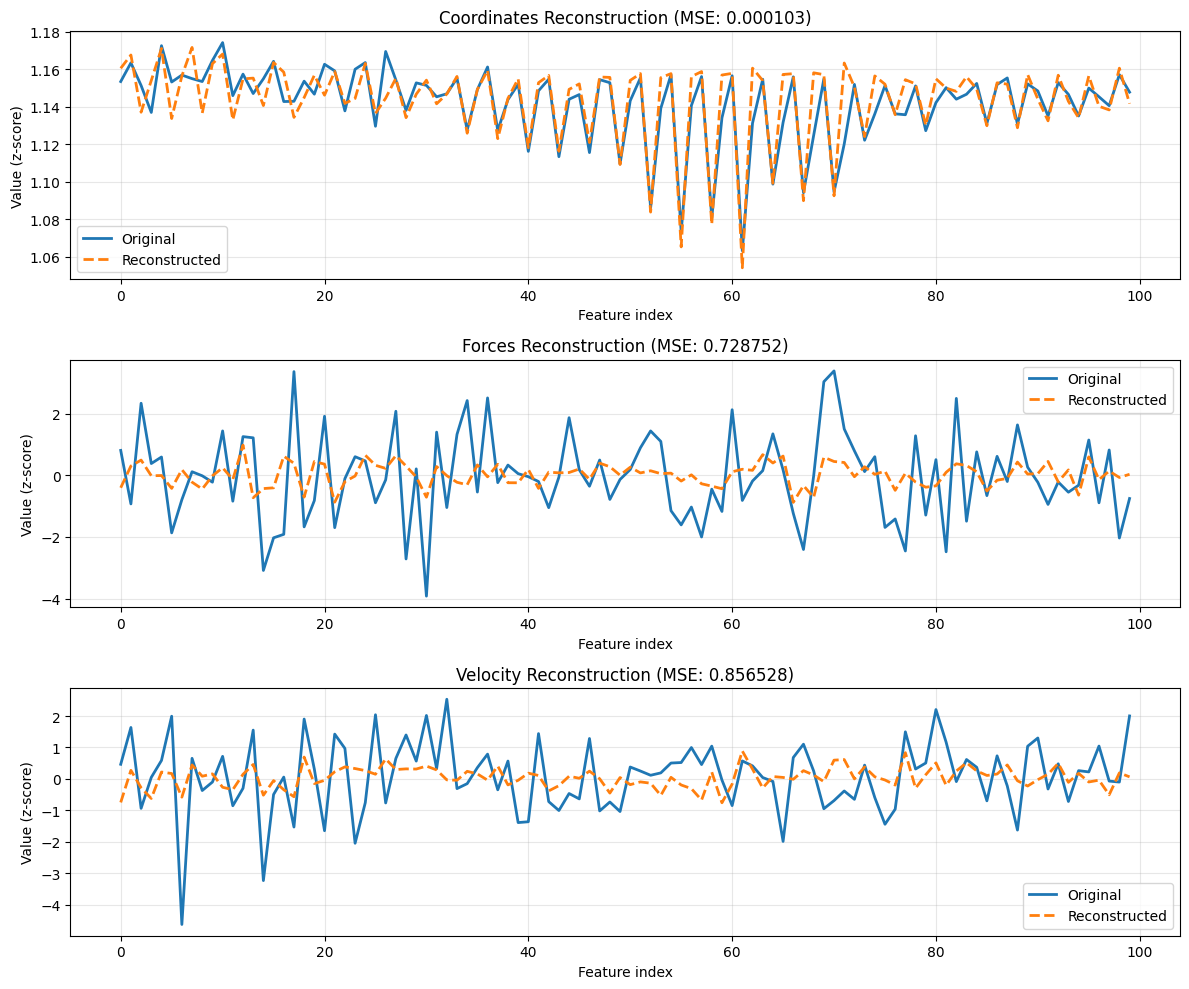


Reconstruction plot saved to processed_step2/autoencoder_reconstruction_all.png


In [7]:
print("=" * 60)
print("RECONSTRUCTION QUALITY CHECK - ALL DATASETS")
print("=" * 60)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

sample_idx = 100
n_features_plot = 100

# Coordinates
reconstructed_coords = autoencoder.predict(data_coords, verbose=0)
axes[0].plot(data_coords[sample_idx, :n_features_plot], label="Original", linewidth=2)
axes[0].plot(reconstructed_coords[sample_idx, :n_features_plot], label="Reconstructed", linestyle="--", linewidth=2)
axes[0].set_title(f"Coordinates Reconstruction (MSE: {np.mean((data_coords - reconstructed_coords)**2):.6f})")
axes[0].set_xlabel("Feature index")
axes[0].set_ylabel("Value (z-score)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Forces
reconstructed_forces = autoencoder_forces.predict(data_forces, verbose=0)
axes[1].plot(data_forces[sample_idx, :n_features_plot], label="Original", linewidth=2)
axes[1].plot(reconstructed_forces[sample_idx, :n_features_plot], label="Reconstructed", linestyle="--", linewidth=2)
axes[1].set_title(f"Forces Reconstruction (MSE: {np.mean((data_forces - reconstructed_forces)**2):.6f})")
axes[1].set_xlabel("Feature index")
axes[1].set_ylabel("Value (z-score)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Velocity
reconstructed_velocity = autoencoder_velocity.predict(data_velocity, verbose=0)
axes[2].plot(data_velocity[sample_idx, :n_features_plot], label="Original", linewidth=2)
axes[2].plot(reconstructed_velocity[sample_idx, :n_features_plot], label="Reconstructed", linestyle="--", linewidth=2)
axes[2].set_title(f"Velocity Reconstruction (MSE: {np.mean((data_velocity - reconstructed_velocity)**2):.6f})")
axes[2].set_xlabel("Feature index")
axes[2].set_ylabel("Value (z-score)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_PATH, "autoencoder_reconstruction_all.png"), dpi=150)
plt.show()

print("\nReconstruction plot saved to processed_step2/autoencoder_reconstruction_all.png")

## Feature Concatenation and Train/Validation/Test Split

### Feature Concatenation

The three latent representations are concatenated into a single feature vector per timestep:

| Component | Dimensions | Description |
|-----------|------------|-------------|
| Latent Coordinates | 32 | Compressed atomic positions |
| Latent Forces | 32 | Compressed atomic forces |
| Latent Velocity | 32 | Compressed atomic velocities |
| **Total** | **96** | Combined feature vector |

### Temporal Split

For time-series data, we must preserve temporal order to avoid data leakage. The split is performed **chronologically**:

| Set | Percentage | Timesteps | Purpose |
|-----|------------|-----------|---------|
| Train | 70% | 0 - 35,000 | Model training |
| Validation | 20% | 35,001 - 45,000 | Hyperparameter tuning |
| Test | 10% | 45,001 - 50,001 | Final evaluation |

This ensures that the model never sees future data during training.

In [8]:
print("=" * 60)
print("FEATURE CONCATENATION AND TRAIN/VAL/TEST SPLIT")
print("=" * 60)

# Create DataFrames with meaningful column names
df_latent_coords = pd.DataFrame(latent_coords, columns=[f"Coord_{i}" for i in range(LATENT_DIM)])
df_latent_forces = pd.DataFrame(latent_forces, columns=[f"Force_{i}" for i in range(LATENT_DIM)])
df_latent_velocity = pd.DataFrame(latent_velocity, columns=[f"Vel_{i}" for i in range(LATENT_DIM)])

# Concatenate
df_final = pd.concat([df_latent_coords, df_latent_forces, df_latent_velocity], axis=1)
print(f"Concatenated shape: {df_final.shape}")
print(f"Columns: {df_final.columns[:5].tolist()} ... {df_final.columns[-5:].tolist()}")

# Temporal split (70/20/10)
n = len(df_final)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_df = df_final.iloc[:train_end].reset_index(drop=True)
val_df = df_final.iloc[train_end:val_end].reset_index(drop=True)
test_df = df_final.iloc[val_end:].reset_index(drop=True)

print(f"\nTemporal split:")
print(f"  Train:      {train_df.shape} (indices 0 - {train_end-1})")
print(f"  Validation: {val_df.shape} (indices {train_end} - {val_end-1})")
print(f"  Test:       {test_df.shape} (indices {val_end} - {n-1})")

# Save to CSV
train_df.to_csv(os.path.join(OUT_PATH, "train_dataset.csv"), index=False)
val_df.to_csv(os.path.join(OUT_PATH, "val_dataset.csv"), index=False)
test_df.to_csv(os.path.join(OUT_PATH, "test_dataset.csv"), index=False)

print(f"\nDatasets saved to {OUT_PATH}/")
print("  - train_dataset.csv")
print("  - val_dataset.csv")
print("  - test_dataset.csv")

FEATURE CONCATENATION AND TRAIN/VAL/TEST SPLIT
Concatenated shape: (50001, 96)
Columns: ['Coord_0', 'Coord_1', 'Coord_2', 'Coord_3', 'Coord_4'] ... ['Vel_27', 'Vel_28', 'Vel_29', 'Vel_30', 'Vel_31']

Temporal split:
  Train:      (35000, 96) (indices 0 - 34999)
  Validation: (10000, 96) (indices 35000 - 44999)
  Test:       (5001, 96) (indices 45000 - 50000)

Datasets saved to processed_step2/
  - train_dataset.csv
  - val_dataset.csv
  - test_dataset.csv


## Supervised Windowing and Time-Series Dataset Generation

### The Windowing Concept

To predict future atomic positions, the model needs to learn from sequences of past observations. We use a **sliding window** approach:

- **Input**: W consecutive timesteps of features (coordinates + forces + velocity)
- **Output**: The coordinates at a future timestep (shift S steps ahead)
```
Time:     t-W+1  t-W+2  ...  t-1    t    t+1   ...  t+S
          |______________________|        |
                 INPUT (W)              TARGET
```

### Configuration

We experiment with different window sizes to understand how much historical context is needed:

| Parameter | Values | Description |
|-----------|--------|-------------|
| Input Width (W) | 10, 30, 60 | Number of past timesteps as input |
| Label Width | 1 | Predict single future timestep |
| Shift (S) | 10 | How far ahead to predict |

### Target Definition

The prediction target is the **latent coordinate representation** (32 dimensions), not the full 414-dimensional coordinates. This means:
- **Input**: 96 features × W timesteps (coordinates + forces + velocity)
- **Target**: 32 features × 1 timestep (future coordinates only)

Forces and velocity are used as **auxiliary input features** to help predict coordinate evolution, but we don't predict them directly.

### Shuffling Strategy

- **Training set**: Shuffled to improve gradient descent optimization
- **Validation/Test sets**: Not shuffled to preserve temporal order for realistic evaluation

In [9]:
print("=" * 60)
print("SUPERVISED WINDOWING")
print("=" * 60)

class WindowGenerator:
    """
    Creates sliding windows for time-series supervised learning.
    """
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 label_columns=None):
        
        # Store data
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        
        # Label columns (what we want to predict)
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}
        
        # Window parameters
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift
        
        self.total_window_size = input_width + shift
        
        # Slices for splitting windows
        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]
        
        self.label_start = self.total_window_size - label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]
    
    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.labels_slice, :]
        
        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_indices[name]] for name in self.label_columns],
                axis=-1
            )
        
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        
        return inputs, labels
    
    def make_dataset(self, data, shuffle):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=32,
        )
        ds = ds.map(self.split_window)
        ds = ds.cache().prefetch(tf.data.AUTOTUNE)
        return ds
    
    @property
    def train(self):
        return self.make_dataset(self.train_df, shuffle=True)
    
    @property
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)
    
    @property
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)
    
    def __repr__(self):
        return "\n".join([
            f"Window Configuration:",
            f"  Input width:  {self.input_width} timesteps",
            f"  Label width:  {self.label_width} timesteps", 
            f"  Shift:        {self.shift} timesteps",
            f"  Total window: {self.total_window_size} timesteps",
            f"  Target cols:  {self.label_columns[:3]}... ({len(self.label_columns)} total)" if self.label_columns else ""
        ])

print("WindowGenerator class defined ✓")

SUPERVISED WINDOWING
WindowGenerator class defined ✓


## Window Creation

We create three window configurations to experiment with different amounts of historical context:

| Configuration | Input Width (W) | Shift (S) | Total Window |
|---------------|-----------------|-----------|--------------|
| Short-term | 10 timesteps | 10 | 20 timesteps |
| Medium-term | 30 timesteps | 10 | 40 timesteps |
| Long-term | 60 timesteps | 10 | 70 timesteps |

The **target columns** are only the coordinate latent dimensions (`Coord_0` to `Coord_31`), as our goal is to predict future atomic positions.

In [10]:
print("=" * 60)
print("CREATING WINDOW CONFIGURATIONS")
print("=" * 60)

# Define target columns (only coordinates - what we want to predict)
label_columns = [f"Coord_{i}" for i in range(LATENT_DIM)]
print(f"Target columns: {label_columns[:3]} ... {label_columns[-3:]}")
print(f"Total targets: {len(label_columns)}")

# Create windows with different input widths
SHIFT = 10  # How far ahead to predict

# Window W=10
w10 = WindowGenerator(
    input_width=10,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_columns
)

# Window W=30
w30 = WindowGenerator(
    input_width=30,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_columns
)

# Window W=60
w60 = WindowGenerator(
    input_width=60,
    label_width=1,
    shift=SHIFT,
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    label_columns=label_columns
)

print("\n--- Window W=10 ---")
print(w10)

print("\n--- Window W=30 ---")
print(w30)

print("\n--- Window W=60 ---")
print(w60)

# Verify shapes
print("\n" + "=" * 60)
print("VERIFYING WINDOW SHAPES")
print("=" * 60)

for name, window in [("W=10", w10), ("W=30", w30), ("W=60", w60)]:
    for batch in window.train.take(1):
        inputs, labels = batch
        print(f"{name}: Input shape = {inputs.shape}, Label shape = {labels.shape}")

CREATING WINDOW CONFIGURATIONS
Target columns: ['Coord_0', 'Coord_1', 'Coord_2'] ... ['Coord_29', 'Coord_30', 'Coord_31']
Total targets: 32

--- Window W=10 ---
Window Configuration:
  Input width:  10 timesteps
  Label width:  1 timesteps
  Shift:        10 timesteps
  Total window: 20 timesteps
  Target cols:  ['Coord_0', 'Coord_1', 'Coord_2']... (32 total)

--- Window W=30 ---
Window Configuration:
  Input width:  30 timesteps
  Label width:  1 timesteps
  Shift:        10 timesteps
  Total window: 40 timesteps
  Target cols:  ['Coord_0', 'Coord_1', 'Coord_2']... (32 total)

--- Window W=60 ---
Window Configuration:
  Input width:  60 timesteps
  Label width:  1 timesteps
  Shift:        10 timesteps
  Total window: 70 timesteps
  Target cols:  ['Coord_0', 'Coord_1', 'Coord_2']... (32 total)

VERIFYING WINDOW SHAPES
W=10: Input shape = (32, 10, 96), Label shape = (32, 1, 32)
W=30: Input shape = (32, 30, 96), Label shape = (32, 1, 32)
W=60: Input shape = (32, 60, 96), Label shape = (

## Dataset Construction Summary

### Dimensionality Reduction Results

| Dataset | Original | Reduced | Method | Reconstruction MSE |
|---------|----------|---------|--------|-------------------|
| Coordinates | 414 | 32 | Autoencoder | ~0.0001 |
| Forces | 414 | 32 | Autoencoder | ~0.73 |
| Velocity | 414 | 32 | Autoencoder | ~0.86 |

### Final Dataset Structure

| Component | Shape | Description |
|-----------|-------|-------------|
| Feature vector | 96 | 32 (coords) + 32 (forces) + 32 (velocity) |
| Train set | 35,000 samples | 70% of data |
| Validation set | 10,000 samples | 20% of data |
| Test set | 5,001 samples | 10% of data |

### Window Configurations

| Config | Input | Target | Use Case |
|--------|-------|--------|----------|
| W=10 | (10, 96) | (1, 32) | Short-term dependencies |
| W=30 | (30, 96) | (1, 32) | Medium-term dependencies |
| W=60 | (60, 96) | (1, 32) | Long-term dependencies |

### Saved Artifacts

All models and data are saved for reproducibility:
- `saved_models/encoder_coordinates.keras`
- `saved_models/encoder_forces.keras`
- `saved_models/encoder_velocity.keras`
- `processed_step2/train_dataset.csv`
- `processed_step2/val_dataset.csv`
- `processed_step2/test_dataset.csv`